## Demo Notebook!

##### Importing Libraries

In [1]:
from evaluation import generate_samples, temperature_generate_samples, get_real_samples, compute_kid, make_sample_grid
from models import device
from diffusers import DDPMPipeline, DDIMScheduler
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import os

c:\Users\niktu\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fixed seed!


### Generation/Inference

##### Initialisation

In [2]:
torch.backends.cudnn.benchmark = True

manual = '' # Used to access some model that isnt automatically named

lr = 1e-5               # lr of the trained model
timesteps = 500         # the timesteps the model was trained on
scheduler = 'ddpm'      # ddpm or ddim scheduler
beta_schedule = 'squaredcos_cap_v2' # ['linear', 'scaled_linear', 'squaredcos_cap_v2', 'sigmoid'] # noise schedule
temp = None            # temperature control
inference_steps = 500 # inference timesteps
n_samples = 64  

lr_f = f"{lr:.0e}".replace("e-0","e-").replace("e+0","e")
model_name = f"ddpm-finetuned-{scheduler}-{beta_schedule}-{timesteps}-{lr_f}-{scheduler}" if not manual else manual

pipeline = DDPMPipeline.from_pretrained("Saved Models/"+ model_name if not manual else manual).to(device) #

path = "Demo Generations/" + model_name + "/"

if not os.path.exists(path):
    os.makedirs(path)

Loading pipeline components...: 100%|██████████| 2/2 [00:00<00:00,  9.26it/s]


##### Generation of Samples

Generating 64 samples...


100%|██████████| 500/500 [00:20<00:00, 24.14it/s]


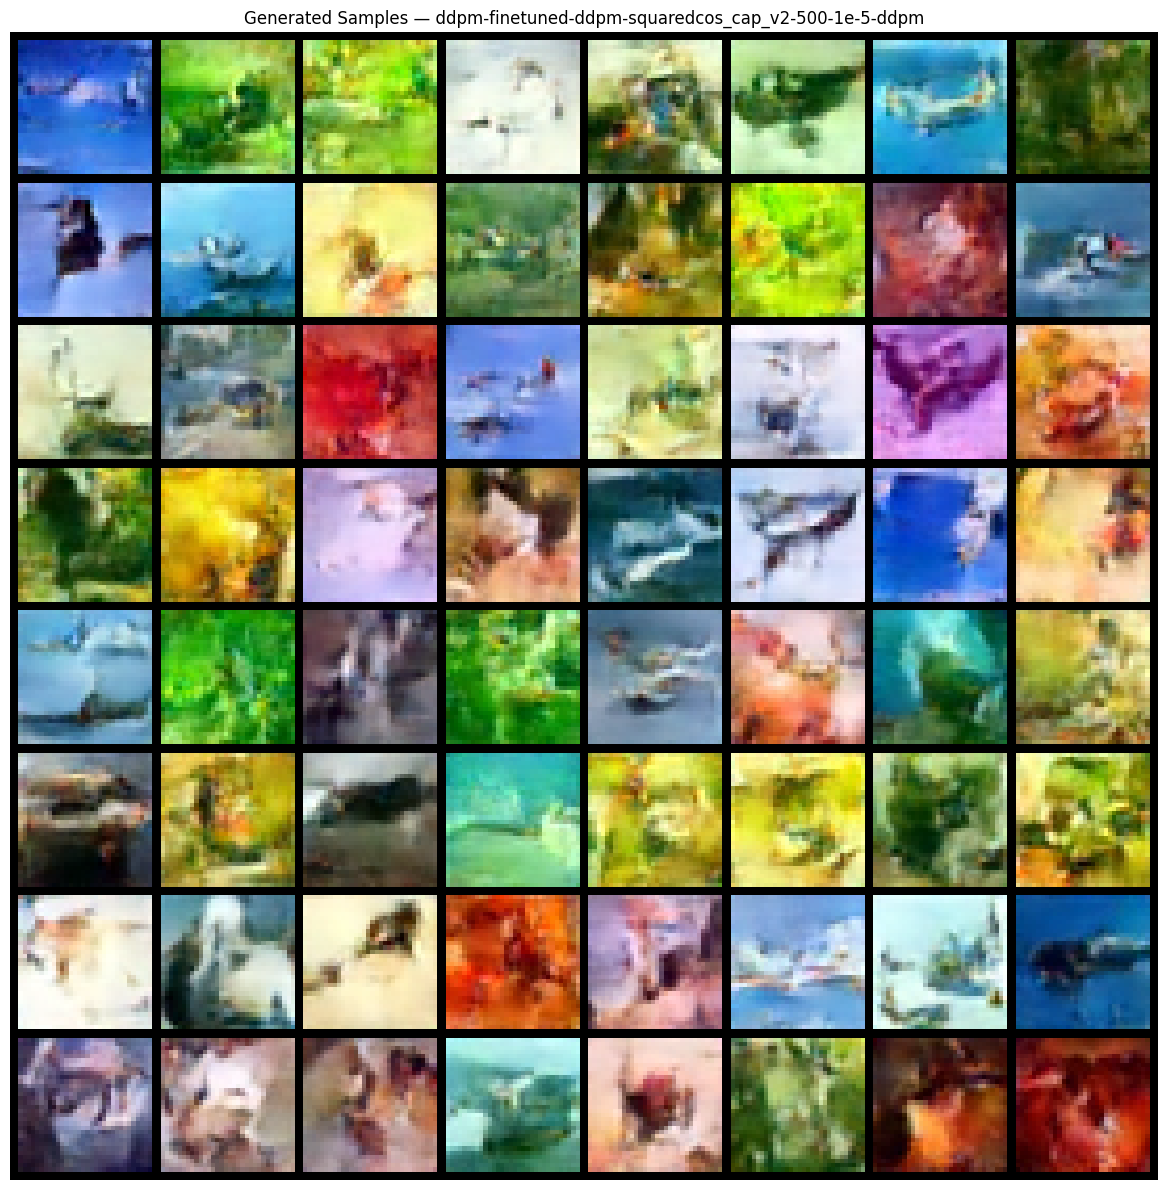

Saved to Demo Generations/ddpm-finetuned-ddpm-squaredcos_cap_v2-500-1e-5-ddpm/demo_generated_500.png


In [3]:
print(f"Generating {n_samples} samples...")

if temp:
    gen_imgs = temperature_generate_samples(pipeline, n_samples, temp=temp, num_inference_steps=inference_steps)
else:
    gen_imgs = generate_samples(pipeline, n_samples, num_inference_steps=inference_steps)

grid = torchvision.utils.make_grid(gen_imgs[:64], nrow=8, padding=2, normalize=True)
plt.figure(figsize=(12, 12))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.title(f"Generated Samples — {model_name}", fontsize=12)
plt.tight_layout()
save_path = path + f'demo_generated_{inference_steps}{"" if not temp else f"_temp{temp}"}.png'
plt.savefig(save_path, dpi=150)
plt.show()
print(f"Saved to {save_path}")

### Evaluation

##### Calculating KID Score and Std.

In [4]:
n_eval = 256
print(f"Loading {n_eval} real samples...")
real_imgs = get_real_samples(n_eval)

print(f"Generating {n_eval} samples for evaluation...")
if temp:
    eval_imgs = temperature_generate_samples(pipeline, n_eval, temp=temp, num_inference_steps=inference_steps)
else:
    eval_imgs = generate_samples(pipeline, n_eval, num_inference_steps=inference_steps)

kid_score, kid_std = compute_kid(real_imgs, eval_imgs, subset_size=50)
print(f"\nKID Score: {kid_score:.4f}")
print(f"KID Std:   {kid_std:.4f}")

Loading 256 real samples...
Generating 256 samples for evaluation...


100%|██████████| 500/500 [00:20<00:00, 23.95it/s]
c:\Users\niktu\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)



KID Score: 0.0816
KID Std:   0.0089


##### Displaying Inference

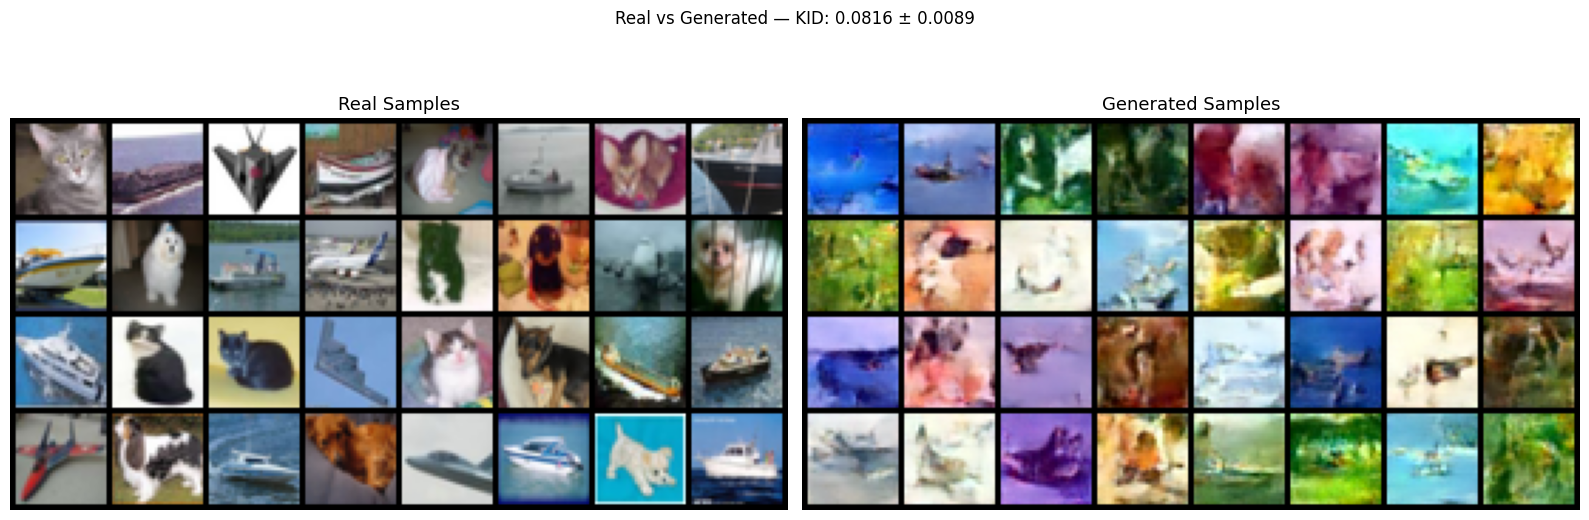

Saved to Demo Generations/ddpm-finetuned-ddpm-squaredcos_cap_v2-500-1e-5-ddpm/demo_comparison.png


In [5]:
n_show = 32

real_grid = torchvision.utils.make_grid(real_imgs[:n_show], nrow=8, padding=2, normalize=True)
gen_grid = torchvision.utils.make_grid(eval_imgs[:n_show], nrow=8, padding=2, normalize=True)


# Code given below for displaying results was made by an LLM
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(real_grid.permute(1, 2, 0).cpu().numpy())
axes[0].set_title('Real Samples', fontsize=13)
axes[0].axis('off')
axes[1].imshow(gen_grid.permute(1, 2, 0).cpu().numpy())
axes[1].set_title('Generated Samples', fontsize=13)
axes[1].axis('off')
plt.suptitle(f'Real vs Generated — KID: {kid_score:.4f} ± {kid_std:.4f}', fontsize=12)
plt.tight_layout()
save_path = path + 'demo_comparison.png'
plt.savefig(save_path, dpi=150)
plt.show()
print(f"Saved to {save_path}")